# **ATTENTION E TRANSFORMER**

## **IDEIA INTUITIVA DE ATTENTION (ATENÇÃO)**

Continuando na área de tradução de frases, quando nós, humanos, vamos traduzir uma frase de um idioma para o outro, principalmente se ela for complicada, primeiro lemos a frase inteira para ter uma ideia geral dela. Após issso, começamos a fazer a tradução da frase e, fazendo isso, normalmente revisitamos partes da frase de origem para que a tradução fique boa. Nesse sentido, o idioma de destino pode ter uma ordem de palavras diferente que a ordem do idioma original, como o seguinte da tradução de francês para ingles: "Zone Économique Européenne" = "European Economic Area". Portanto, podemos saltar pela frase de origem para encontrar uma palavra específica quando for a hora de sua tradução aparecer na frase de destino.

Paralelo a isso, pensando em uma rede neural, parece ser aceitável acreditar que uma rede se beneficiaria de poder decidir por si mesma em que parte dos dados de entrada focar em cada passo de tempo.

## **ATTENTION EM REDES SEQ2SEQ**

Um problema observado em redes *seq2seq*, como a do material passado, é a dificuldade em lidar com frases longas. Isso faz sentido, pois imagine um vetor de tamanho fixo (por exemplo 8), que corresponde ao estado interno do *encoder* no último passo de tempo (o contexto), ter que representar uma frase extensa (por exemplo, com 70 palavras). 

Uma mudança no *encoder* para resolver isso é, em vez de descartar os estados internos de todos os passos de tempo e segurar só o último, "guardar" os estados internos de cada passo de tempo. O conjunto desses vetores é conhecido como **estado oculto de origem**. Com isso, teremos o estado interno do *encoder* para a palavra atual e, também, para as outras palavras históricas na frase.

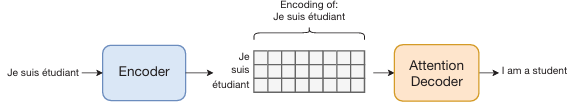 *Como fica essa mudança no encoder*

Para o *decoder*, as alterações são mais complexas. O *decoder* baseado em *attention* faz o seguinte para cada passo de tempo:

1. Calcula um *score* de alinhamento para cada vetor de estado (para cada vetor presente na imagem acima). Esse *score* determina quanta atenção prestar a esse vetor de estado no passo de tempo atual. 
2. Usa uma *softmax* para normalizar esses *scores* para que somem 1. Esse vetor normalizado é conhecido como vetor de alinhamento e consiste na quantidade de vetores de estado que existem, ou seja, como na imagem acima temos 3 vetores de estado, esse vetor de alinhamento teria 3 valores.
3. Multiplica cada vetor de estado por seu *score* de alinhamento. Após isso, soma-se os vetores resultantes elemento a elemento, resultando em um vetor de mesma dimensão que na rede sem atenção.
4. O vetor resultante é usado como entrada para o *decoder* durante esse passo de tempo. Assim como na rede sem atenção, este vetor é concatenado com o *embedding* do passo de tempo anterior para formar a entrada geral para a camada recorrente.


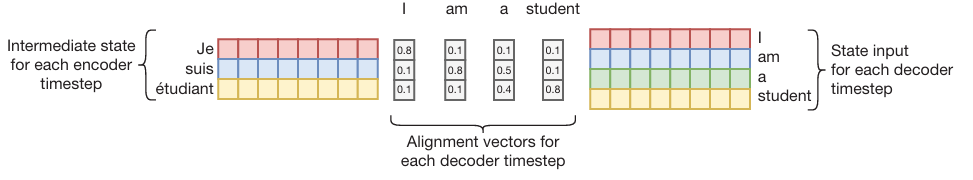 *Exemplificação do que foi explicado acima. No primeiro passo de tempo, ou seja, para a saída 'I', o score de alinhamento é calculado para cada vetor de estado (para cada um dos 3 vetores de entrada) e passa por uma softmax, resultando no vetor de 3 dimensões abaixo de 'I'. Após isso, multiplica-se o vetor de estado de cada passo de tempo (de cada cor) pelo seu score de alinhamento calculado e soma-se esses vetores (elemento a elemento). O vetor resultante, nesse caso o vermelho da direita, é usado como entrada para o decoder.*

Ao analisar os *scores* de alinhamento da imagem acima, nota-se que o *decoder* manterá seu foco em *'je'* durante o primeiro passo de tempo, o que resulta na saída de **'I'**. Isso comprova o uso do mecanismo de atenção, pois a palavra com maior 'foco', ou seja, com maior *score* de pontuação durante o passo de tempo que irá gerar **'I'** é o vetor da palavra *'je'*. A codificação por cores ilustra isso (a primeira entrada do *decoder* é vermelha, assim como a primeira saída do *encoder*). Ele focará principalmente em *'suis'* ao produzir *'am'*. Ao produzir *'a'*, ele foca tanto em *'suis'* quanto em *'étudiant'* (o vetor de entrada é verde, que é uma mistura de azul e amarelo). Finalmente, seu foco está em *'étudiant'* ao produzir *'student'*.

Os autores que proporam esse método de *attention* (Bahdanau, Cho e Bengio) analisaram um exemplo mais complexo:

* Francês: L’ accord sur la **zone économique européenne** a été signé en août 1992.

* Inglês: The agreement on the **European Economic Area** was signed in August 1992.

Essas palavras em negrito foram citadas acima. A ordem das palavras é diferente em francês do que em inglês (*zone* corresponde a *Area*, e *européenne* corresponde a *European*). Os autores mostram que para todos os três passos de tempo, quando o *decoder* produz *European Economic Area*, as pontuações de alinhamento para todas as três palavras *zone économique européenne* são altas. Ou seja, o *decoder* está prestando atenção às palavras vizinhas para chegar a uma tradução correta.

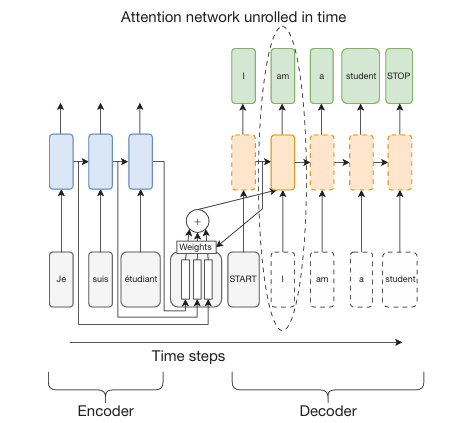 *Rede com atenção desenrolada pelo tempo*

Com base nessa imagem, nota-se que os retângulos brancos, que estão no meio da imagem, representam os estados internos do *encoder*. Como descrito acima, para produzir um único vetor, que será usado como entrada para a entrada recorrente do *decoder*, realiza-se uma soma ponderada desses vetores presentes no meio da imagem. Os pesos, que são os *scores* de alinhamento, são ajustáveis e recalculados a cada passo de tempo. Esses pesos são controlados pelo estado interno do *decoder* do passo de tempo anterior ao passo de tempo atual dele. Ou seja, o *decoder* é responsável por calcular as pontuações de alinhamento. Com isso, nota-se que o próprio *decoder* controla o quanto de cada vetor de estado do *encoder* usar como sua entrada.

### **COMO CALCULAR ESSE VETOR DE ALINHAMENTO**

Um vetor de alinhamento consiste em *Te* elementos, onde *Te* é o número de passos de tempo para o *encoder*. Precisamos calcular *Td* desses vetores, onde *Td* é o número de passos de tempo para o *decoder*. 

Pode-se imaginar múltiplas maneiras de calcular o vetor de alinhamento. Sabemos que ele precisa ter comprimento *Te*. Também precisamos decidir quais valores de entrada usar para calcular o vetor. Finalmente, precisamos decidir qual computação aplicar a esses valores de entrada para produzir as pontuações.

Um candidato óbvio para valor de entrada é o estado do *decoder*, porque queremos que o *decoder* seja capaz de escolher dinamicamente em que partes da entrada focar (isso foi comentado acima já). Outro candidato que pode ser usado como valor de entrada para essa computação é o **estado oculto de origem**. Encarando o estado oculto de origem como uma memória, isso significa que usamos o conteúdo dessa memória para endereçar qual parte da memória ler, um conceito conhecido como memória endereçável por conteúdo (CAM).

No exemplo explicado acima, o estado do *decoder* é usado como uma *query* (consulta). Ele é usado para corresponder a uma chave (*key*), que no exemplo acima é o estado oculto de origem. Isso seleciona o valor (*value*) a ser retornado, que nesse caso acima também é o estado oculto de origem (a chave e o valor podem ser diferentes um do outro).

Agora falta decidir a função que será usada para "levar" a consulta à chave. Não é exagero usar uma rede neural para essa função e deixar o modelo aprender a função por si só.

### **E POR QUÊ FUNCIONA?**

Para entender a intuição por trás do mecanismo de atenção, podemos pensar em termos de representação espacial em um espaço de N dimensões (onde N é a dimensionalidade do modelo).

Antes de continuarmos, lembre da analogia com bancos de dados (claro que aqui temos um siginificado mais profundo): 
- **QUERY**: Uma consulta que representa "o que estamos procurando" no momento atual (pode vir tanto do *decoder* quanto do *encoder* em *self-attention*)
- **KEY**: Representações que capturam a similaridade semântica entre diferentes palavras/posições na sequência - o objetivo principal é entender como *X* palavras se relacionam com *Y* palavras em termos de significado
- **VALUE**: O resultado obtido quando aplicamos a *query* às atenções calculadas pelas *KEYs* - é a informação final que extraímos baseada nas similaridades encontradas

No espaço vetorial do modelo, cada *QUERY* representa um ponto específico que corresponde ao que estamos "falando" no momento. As *KEYs* não são apenas identificadores de posição, mas sim representações semânticas que permitem medir o quão relacionadas diferentes palavras estão entre si. Quando calculamos os scores de atenção (*QUERY × KEY*), estamos medindo similaridade representacional no espaço semântico, isso é, o quão de "atenção" eu devo estar observando nessa palavra para sintetizar ou representar uma frase.

Quando calculamos os scores de atenção, estamos perguntando: "dada esta consulta (*QUERY*), quais representações (*KEYs*) são semanticamente mais similares?", com isso, os scores altos indicam alta similaridade representacional, e são usados para ponderar os *VALUES* correspondentes. O *VALUE* final é então o resultado dessa consulta aplicada às atenções - uma combinação informada das representações mais relevantes, ou seja, eu estou falando que aquela palavra X tem o peso Y, nada mais do que ponderar as representações baseado em uma "atenção".

Então, o que estamos fazendo é permitindo que o modelo aprenda automaticamente as relações semânticas entre diferentes partes da sequência. Em vez de processar palavras isoladamente, o modelo pode capturar como palavras se relacionam umas com as outras em termos de significado e contexto. Portanto, retornando uma "*attention*" para o input. 

### **PONTOS ADICIONAIS**

No mecanismo de *attention* descrito, o *decoder* cria uma soma ponderada dos vetores no estado oculto de origem. Isso é conhecido como atenção suave (*soft attention*). Uma alternativa é, em vez disso, deixar o *decoder* atender a apenas um dos vetores no estado oculto de origem para cada passo de tempo. Isso é conhecido como atenção rígida (*hard attention*).

Na *hard attention*, o estado de um único passo de tempo do *encoder* é selecionado para focar em cada passo de tempo do *decoder*. Na *soft attention*, uma mistura (soma ponderada) do estado de todos os passos de tempo do *encoder* é usada.

Uma lição desta discussão é que a atenção é um conceito geral, e existem múltiplas maneiras potenciais de implementá-la. Com isso, fica a dúvida: "Qual é a maneira certa de implementar, então?" Na realidade, provavelmente não existe uma única maneira certa de aplicar esses conceitos. Diferentes implementações expressam comportamentos ligeiramente diferentes e vêm com diferentes níveis de eficiência em termos de quanta computação é necessária para alcançar um determinado resultado.

## **ALTERNATIVA A REDES RECORRENTES**

Vale a pena refletir sobre a seguinte questão: "As redes recorrentes são necessárias para a tarefa de tradução?". Decidimos usar redes recorrentes devido a capacidade em processar sequências de comprimento variável tanto para entrada quanto para saída. A rede *encoder-decoder* baseada em *RNN* foi uma boa solução para isso com uma representação intermediária de tamanho fixo. Para obter boas traduções de frases longas, foi introduzido o *attention*. Com esse histórico, é natural explorar se é necessário uma *RNN* para construir o *encoder* ou se outras arquiteturas de rede são tão boas ou melhores. Outro problema com a implementação baseada em *RNN* é que as *RNNs* são inerentemente de natureza serial. As computações não podem ser paralelizadas tão bem quanto em outras arquiteturas de rede, levando a longos tempos de treinamento. 

Um avanço na área de *NLP* veio com a introdução da arquitetura *Transformer*, que não usa nem camadas recorrentes nem camadas convolucionais. Ela é baseada em camadas *fully-connected*, *self-attention* e *multi-head attention*. Um benefício chave da arquitetura *Transformer* é que ela é de natureza paralela.

## **SELF-ATTENTION**

### **IDEIA INTUITIVA**

Pense que a seguinte frase é uma frase de entrada que queremos traduzir:

```
The animal didn't cross the street because it was too tired
```

*'it'* se refere a o quê nesta frase? Refere-se à rua ou ao animal? Isso é uma pergunta simples para um humano, porém não é tão simples assim para um computador.

Quando o modelo está processando a palavra *'it'*, o mecanismo de *self-attention* permite que ele associe *'it'* a *'animal'*. Logo, diferente do mecanismo de *attention* já explicado acima - que recebe os contextos do *encoder* e decidi focar em uma parte específica da sequência de entrada para gerar a sequência de saída -, o *self-attention* aprende a relação entre as palavras que são o *input* da rede e recebe as entradas diretamente da camada anterior (que costuma ser do *encoder*).

A cada vez que o modelo processa uma palavra, o *self-attention* permite que ele observe outras posições na sequência de entrada em busca de pistas que possam ajudar a levar a uma melhor codificação para essa palavra.

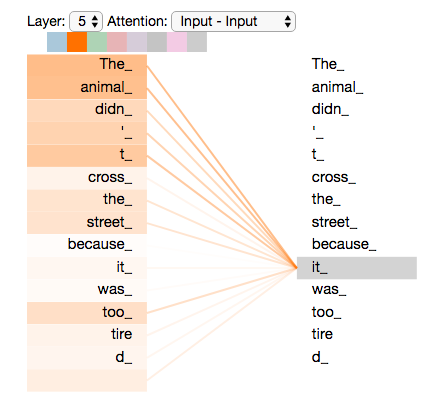 *Nessa imagem, nota-se que, ao codificar a palavra 'it', o mecanismo de attention deu um foco maior em 'The animal'.*

### **SELF-ATTENTION EM DETALHES (TRANSFORMER)**

Primeiramente, os *inputs* da rede são organizados de forma matricial em uma matriz **X**, onde cada linha corresponde a uma palavra do exemplo de treinamento (cada palavra já está organizada em um vetor de *word embedding*). Depois disso, precisamos calcular as matrizes **Q** (*query*), **K** (*key*) e **V** (*value*). Para isso, pegamos a matriz **X** e multiplicamos pelas matrizes de pesos que são aprendidas durante o treinamento (**W_Q**, **W_K**, **W_V**), obtendo as matrizes **Q**, **K** e **V**.

Após isso, calculamos um *score* por meio da mutiplicação de **Q** por **K**. Com isso, obtenho uma matriz que pontua a relação de cada palavra de entrada com cada palavra da frase de *input*. Porém, os números que formam essa matriz tendem a ser muito grandes, devido ao cálculo dessa matriz. A partir disso, divido cada número da matriz pela dimensão da matriz **K**, pois isso leva a gradientes mais estáveis, e passo o resultado por uma *softmax*, que normaliza as pontuações para que todas sejam positivas e somem 1. O resultado disso é uma matriz que determina o quanto cada palavra será expressa nesta posição, ou seja:

* **Pontuações mais altas = maior atenção**

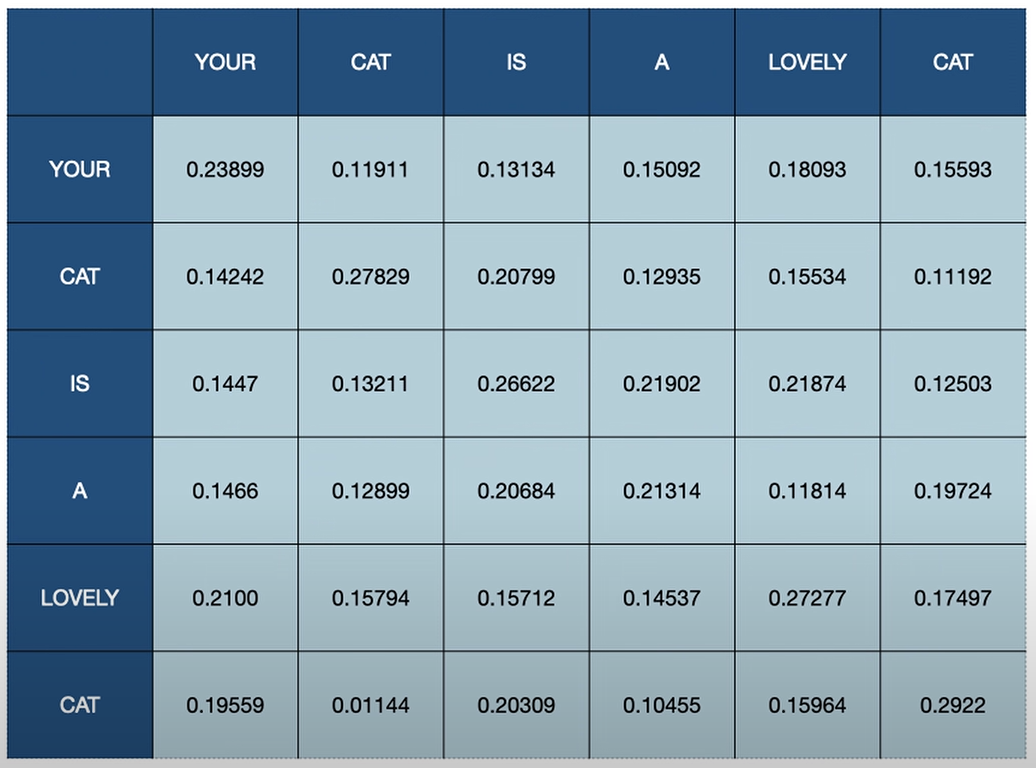 *Exemplo dessa matriz. O elemento 1,1 da matriz representa o produto escalar do embedding da palavra 'your' com ela mesmo, o elemento 1,2 representa o produto escalar do embedding da palavra 'your' com o da palavra 'cat' e assim por diante.*

Com essa matriz de pontuação obtida, é necessário multiplicá-la pela matriz **V**. A intuição aqui é manter intactos os valores da(s) palavra(s) em que queremos focar e abafar palavras irrelevantes.

Isso que foi explicado acima pode ser resumido em uma fórmula:

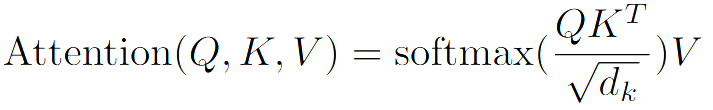 *Fórmula para o cálculo da attention*